# Architecture of filters

So, the english is not very good, I will improve that

In [230]:
import itertools

import sympy as sy
import numpy as np

from sympy import Matrix
from sympy.physics.quantum import TensorProduct

In [231]:
import fitz

from utils import plot_pdf, plot_pdf2col, symmetrical_cyclic_convolution

In [232]:
from sympy import init_printing
init_printing(use_latex='png', forecolor='White', backcolor='Black')

In [233]:
doc = fitz.open('Blahut_2010_Fast algorithms for signal processing.pdf')

The base for this tutorial is the book "Fast Algorithms or Signal Processing" of Blahut.

This tutorial not work with others vector sizes

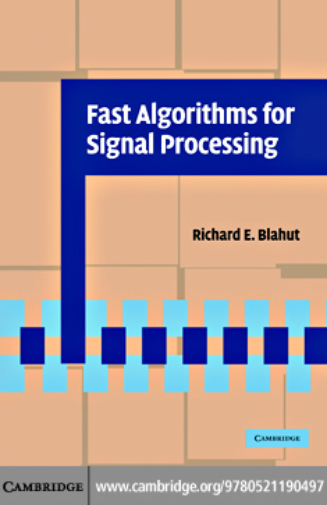

In [234]:
plot_pdf(doc[0], dpi=100)

## Polynomials

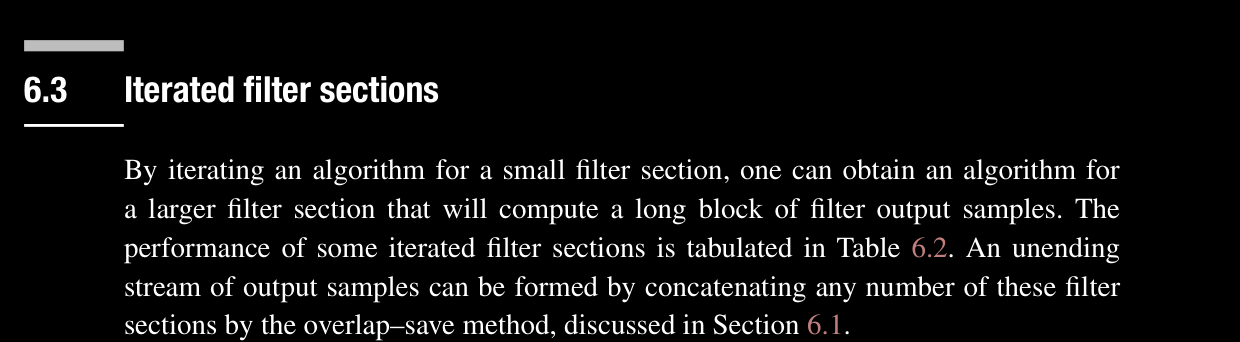

In [235]:
plot_pdf(doc[217], [.6, .78])

Size of vectors

In [236]:
v_size = 2

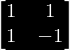

In [237]:
win = sy.Matrix([[1, 1], [1, -1]])
win

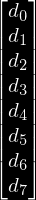

In [238]:
d2 = sy.Matrix(sy.symbols(" ".join(f"d_{i}"for i in range(v_size*4))))
d2

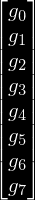

In [239]:
g2 = sy.Matrix(sy.symbols(" ".join(f"g_{i}"for i in range(v_size*4))))
g2

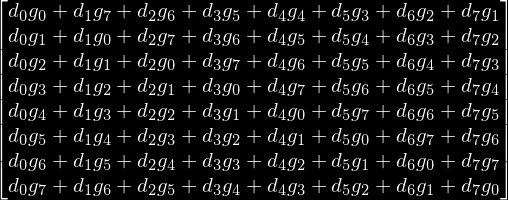

In [240]:
cc2 = sy.Matrix(symmetrical_cyclic_convolution(np.array(d2).reshape(-1), np.array(g2).reshape(-1)))
cc2

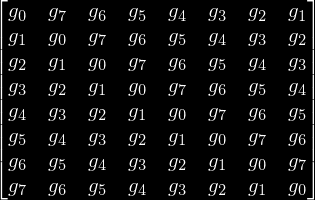

In [241]:
cc2_args = [[arg for mul in line.args for arg in mul.args if 'g' in arg.name] for line in cc2]
sy.Matrix(cc2_args)

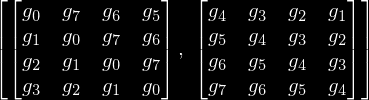

In [242]:
cc2_args = np.array(cc2_args)
g2m = [sy.Matrix(cc2_args[r:r+4, c:c+4].tolist()) for r in range(0, cc2_args.shape[0], 4) for c in range(0, cc2_args.shape[1]//2, 4)]
g2m

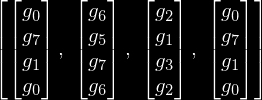

In [243]:
g1m0 = [
    sy.Matrix(g2m[0][r:r+2, c:c+2].reshape(4, 1).tolist())
    for r in range(0, g2m[0].shape[0], 2)
    for c in range(0, g2m[0].shape[1], 2)
]
g1m0

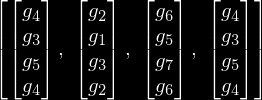

In [244]:
g1m1 = [
    sy.Matrix(g2m[1][r:r+2, c:c+2].reshape(4, 1).tolist())
    for r in range(0, g2m[1].shape[0], 2)
    for c in range(0, g2m[1].shape[1], 2)
]
g1m1

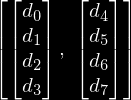

In [246]:
d2m = [
    sy.Matrix(d2[0:4]),
    sy.Matrix(d2[4:8])
]
d2m

In [247]:
ii = sy.symbols('I')
ii

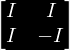

In [248]:
win_ii = sy.Matrix([
    [ii, ii], 
    [ii, -ii]
])
win_ii

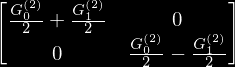

In [249]:
gg2m = sy.diag(*[
    gg2[0] + gg2[1], 
    gg2[0] - gg2[1]
])* 1/2
gg2m

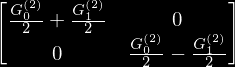

In [250]:
sy.diag(*(win * gg2/2).flat())

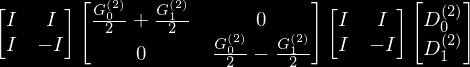

In [251]:
sy.MatMul(win_ii, gg2m, win_ii, dd2)

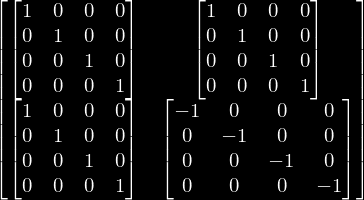

In [252]:
win_ii2.subs({ii: sy.eye(2)})

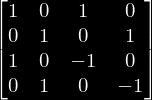

In [253]:
win1 = sy.Matrix([
    [sy.eye(2), sy.eye(2)], 
    [sy.eye(2), -sy.eye(2)]
])
win1

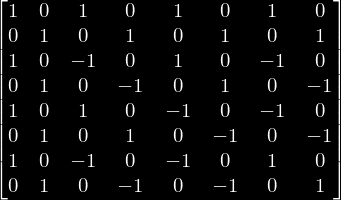

In [254]:
win2_old = sy.Matrix([
    [win1, win1], 
    [win1, -win1]
])
win2_old

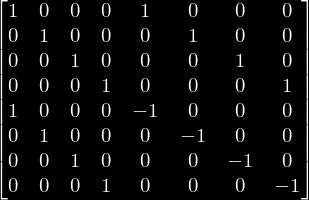

In [255]:
win2 = TensorProduct(win, sy.eye(4))
win2

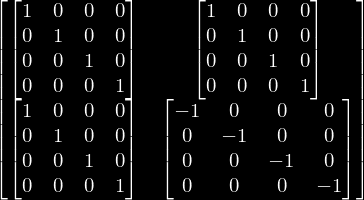

In [256]:
win_ii.subs({ii: sy.eye(4)})


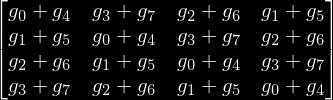

In [257]:
g1m0 = sy.Matrix([
    g2m[0][0,::] + g2m[1][0,::], 
    g2m[0][1,::] + g2m[1][1,::],
    g2m[0][2,::] + g2m[1][2,::], 
    g2m[0][3,::] + g2m[1][3,::]
])
g1m0

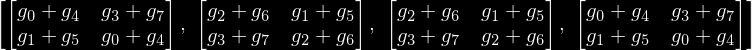

In [258]:
g0m0 = [
    sy.Matrix(g1m0[r:r+2, c:c+2].reshape(2, 2).tolist())
    for r in range(0, g1m0.shape[0], 2)
    for c in range(0, g1m0.shape[1], 2)
]
g0m0

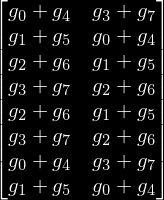

In [259]:
bg0m0 = sy.Matrix([
    g0m0[0], g0m0[1], 
    g0m0[2], g0m0[3]
])
bg0m0

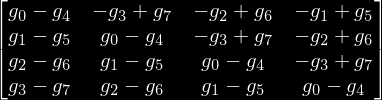

In [260]:
g1m1 = sy.Matrix([
    g2m[0][0,::] - g2m[1][0,::], 
    g2m[0][1,::] - g2m[1][1,::],
    g2m[0][2,::] - g2m[1][2,::], 
    g2m[0][3,::] - g2m[1][3,::]
])
g1m1

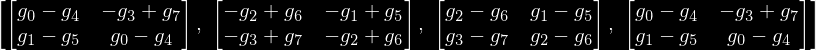

In [261]:
g0m1 = [
    sy.Matrix(g1m1[r:r+2, c:c+2].reshape(2, 2).tolist())
    for r in range(0, g1m1.shape[0], 2)
    for c in range(0, g1m1.shape[1], 2)
]
g0m1

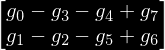

In [262]:
bg1m1 = sy.Matrix([
    g1m1[0] + g1m1[1], 
    g1m1[2] - g1m1[3]
])
bg1m1

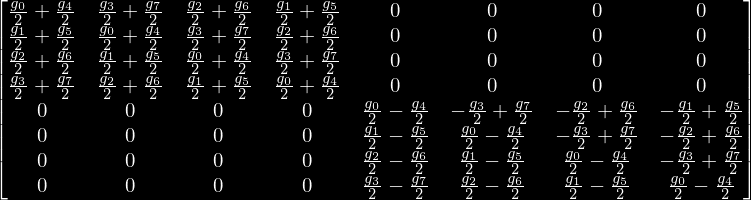

In [263]:
bg2 = sy.diag(*[
    g2m[0] + g2m[1], 
    g2m[0] - g2m[1]
])/2
bg2

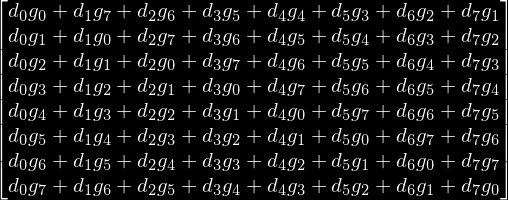

In [264]:
cc = sy.Matrix(symmetrical_cyclic_convolution(np.array(d2).reshape(-1), np.array(g2).reshape(-1)))
cc

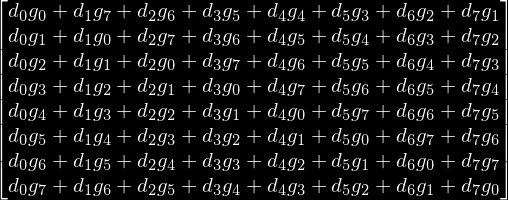

In [265]:
ssx = sy.MatMul(win2, bg2, win2, d2, evaluate=True)
ssx

In [266]:
np.all(np.array(cc) == np.array(ssx))

True

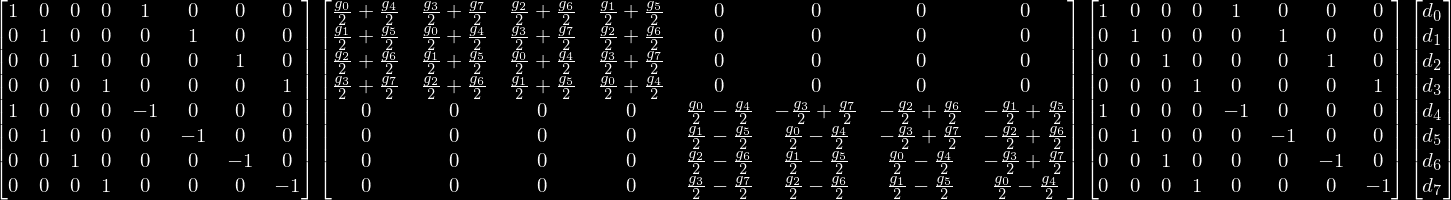

In [267]:
ssx = sy.MatMul(win2, bg2, win2, d2)
ssx

In [268]:
import random
val_d = [random.randint(0, 2**10) for r in range(8)]
val_g = [random.randint(0, 2**10) for r in range(8)]

In [269]:
subs_g = {k: v for k, v in zip(g2.flat(), val_g)}
subs_g

In [270]:
subs_d = {k: v for k, v in zip(g2.flat(), val_d)}
subs_d

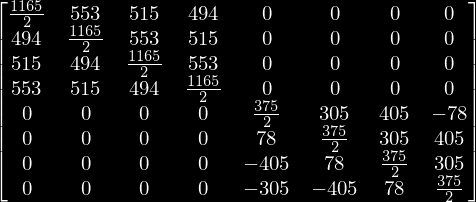

In [271]:
bg2_subs = bg2.subs(subs_g)
bg2_subs

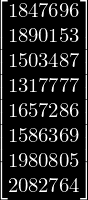

In [281]:
cout = sy.Matrix(symmetrical_cyclic_convolution(val_d, val_g))
cout

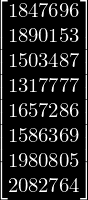

In [273]:
r = win2 * bg2_subs * win2 * sy.Matrix(val_d)
r

In [282]:
np.all(np.array(cout) == np.array(r))

True

Testes como FFT

In [274]:
np.fft.fft(val_d)

array([3233.          +0.j        ,  837.94469683-157.42196898j,
       -192.        -395.j        ,  630.05530317-941.42196898j,
       1111.          +0.j        ,  630.05530317+941.42196898j,
       -192.        +395.j        ,  837.94469683+157.42196898j])

In [275]:
fft = (np.fft.fft(val_d))
fft.real - fft.imag

array([3233.        ,  995.36666582,  203.        , 1571.47727215,
       1111.        , -311.36666582, -587.        ,  680.52272785])

In [276]:
fft.real + fft.imag

array([3233.        ,  680.52272785, -587.        , -311.36666582,
       1111.        , 1571.47727215,  203.        ,  995.36666582])

Se eu meter um número imaginário $i$ em alguns lugares oq será q acontece? 

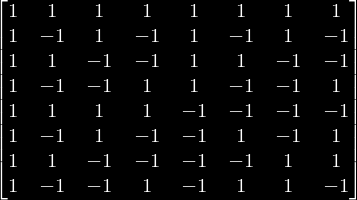

In [277]:
winft = TensorProduct(win, win, win)
winft

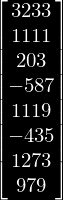

In [278]:
winft * sy.Matrix(val_d)

In [279]:
np.fft.fft([3,10])

array([13.+0.j, -7.+0.j])

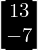

In [280]:
win * sy.Matrix([3, 10])